# Deep RL notebook for the symbolic grid rearrangement puzzle

This notebook moves beyond the tabular Q-learning baseline and supports **three deep RL agents**:

- **DQN**
- **Double DQN**
- **PPO**

It lets you:

1. configure a larger symbolic puzzle such as **4x4 with 10 objects**
2. train any subset of the three agents
3. save the trained checkpoints
4. reload the checkpoints later
5. evaluate all saved models on the **same puzzle sample** and compare their performance

The environment remains a symbolic MDP with deterministic transitions and a goal-conditioned observation.

## Install packages

Run the next cell once. It only installs the external packages used by this notebook.

In [1]:
%pip install -q numpy matplotlib torch

Note: you may need to restart the kernel to use updated packages.


## Core implementation

The next cell writes the deep-RL helper module to `gridworld_deep_rl.py` and makes the notebook self-contained.

In [2]:
%%writefile gridworld_deep_rl.py
#!/usr/bin/env python3
"""Deep RL agents for the symbolic grid rearrangement puzzle.

Included algorithms:
- DQN
- Double DQN
- PPO

The environment is a symbolic 2D rearrangement puzzle with labeled objects,
empty cells, deterministic transitions, and a goal-conditioned observation.

This module is designed for notebook use but can also be imported from scripts.
"""

from __future__ import annotations

import json
import math
import random
from dataclasses import asdict, dataclass, field
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch

torch.set_num_threads(1)
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical

EMPTY = -1
DIRS: Tuple[Tuple[int, int], ...] = ((-1, 0), (1, 0), (0, -1), (0, 1))
DIR_NAMES: Tuple[str, ...] = ("up", "down", "left", "right")


# ---------------------------------------------------------------------------
# Utilities
# ---------------------------------------------------------------------------


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)



def row_col_to_index(r: int, c: int, size: int) -> int:
    return r * size + c



def index_to_row_col(idx: int, size: int) -> Tuple[int, int]:
    return divmod(idx, size)



def count_correct_objects(state: Sequence[int], goal: Sequence[int], n_objects: int) -> int:
    correct = 0
    for obj_id in range(n_objects):
        if state.index(obj_id) == goal.index(obj_id):
            correct += 1
    return correct



def moving_average(values: Sequence[float], window: int = 50) -> np.ndarray:
    if len(values) == 0:
        return np.array([], dtype=np.float32)
    out = np.zeros(len(values), dtype=np.float32)
    for i in range(len(values)):
        lo = max(0, i - window + 1)
        out[i] = float(np.mean(values[lo : i + 1]))
    return out



def board_to_onehot(board: Sequence[int], n_objects: int) -> np.ndarray:
    board_arr = np.asarray(board, dtype=np.int64)
    n_cells = board_arr.shape[0]
    channels = n_objects + 1  # channel 0 is EMPTY, channels 1..N are objects 0..N-1
    out = np.zeros((n_cells, channels), dtype=np.float32)
    idx = np.where(board_arr == EMPTY, 0, board_arr + 1)
    out[np.arange(n_cells), idx] = 1.0
    return out.reshape(-1)



def encode_observation(state: Sequence[int], goal: Sequence[int], n_objects: int) -> np.ndarray:
    return np.concatenate([board_to_onehot(state, n_objects), board_to_onehot(goal, n_objects)]).astype(
        np.float32
    )



def masked_argmax(q_values: torch.Tensor, action_mask: torch.Tensor) -> torch.Tensor:
    masked = q_values.masked_fill(~action_mask, -1e9)
    return masked.argmax(dim=-1)



def ensure_device(device: Optional[str] = None) -> torch.device:
    if device is not None:
        return torch.device(device)
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ---------------------------------------------------------------------------
# Environment
# ---------------------------------------------------------------------------


@dataclass
class EnvConfig:
    size: int = 4
    n_objects: int = 10
    move_mode: str = "step"
    scramble_steps: int = 12
    max_steps: int = 60
    step_penalty: float = -0.3
    invalid_penalty: float = -0.7
    goal_reward: float = 12.0
    shaping_scale: float = 0.4
    random_goal: bool = False
    seed: int = 0


@dataclass
class StepResult:
    observation: Dict[str, Tuple[int, ...]]
    reward: float
    done: bool
    info: Dict[str, object]


class GridRearrangementEnv:
    """Goal-conditioned symbolic rearrangement environment.

    State: positions of all labeled objects on a size x size grid with empty cells.
    Action: (object_id, direction) encoded into one discrete integer.
    Transition: deterministic under either step or slide dynamics.
    """

    def __init__(self, config: EnvConfig):
        if config.size < 2:
            raise ValueError("size must be at least 2")
        if config.n_objects < 1:
            raise ValueError("n_objects must be at least 1")
        if config.n_objects >= config.size * config.size:
            raise ValueError("n_objects must be smaller than number of cells")
        if config.move_mode not in {"step", "slide"}:
            raise ValueError("move_mode must be 'step' or 'slide'")

        self.config = config
        self.size = config.size
        self.n_cells = self.size * self.size
        self.n_objects = config.n_objects
        self.num_actions = self.n_objects * 4
        self.rng = random.Random(config.seed)

        self.goal: Tuple[int, ...] = self._canonical_goal()
        self.state: Tuple[int, ...] = self.goal
        self.steps_taken = 0

    @property
    def obs_dim(self) -> int:
        return 2 * self.n_cells * (self.n_objects + 1)

    def _canonical_goal(self) -> Tuple[int, ...]:
        cells = [EMPTY] * self.n_cells
        for obj_id in range(self.n_objects):
            cells[obj_id] = obj_id
        return tuple(cells)

    def _validate_layout(self, layout: Sequence[int]) -> Tuple[int, ...]:
        if len(layout) != self.n_cells:
            raise ValueError(f"layout must have length {self.n_cells}")
        arr = list(layout)
        expected = sorted([EMPTY] * (self.n_cells - self.n_objects) + list(range(self.n_objects)))
        if sorted(arr) != expected:
            raise ValueError("layout must contain each object exactly once and fill remaining cells with EMPTY")
        return tuple(int(x) for x in arr)

    def _sample_random_layout(self) -> Tuple[int, ...]:
        cells = [EMPTY] * self.n_cells
        positions = self.rng.sample(range(self.n_cells), self.n_objects)
        for obj_id, pos in enumerate(positions):
            cells[pos] = obj_id
        return tuple(cells)

    def _action_to_parts(self, action: int) -> Tuple[int, int]:
        if action < 0 or action >= self.num_actions:
            raise ValueError(f"invalid action index {action}")
        return action // 4, action % 4

    def action_to_str(self, action: int) -> str:
        obj_id, dir_idx = self._action_to_parts(action)
        return f"obj={obj_id} {DIR_NAMES[dir_idx]}"

    def _find_object(self, state: Sequence[int], obj_id: int) -> Optional[int]:
        try:
            return tuple(state).index(obj_id)
        except ValueError:
            return None

    def _apply_action_to_state(self, state: Sequence[int], action: int) -> Tuple[Tuple[int, ...], bool]:
        obj_id, dir_idx = self._action_to_parts(action)
        pos = self._find_object(state, obj_id)
        if pos is None:
            return tuple(state), False

        r, c = index_to_row_col(pos, self.size)
        dr, dc = DIRS[dir_idx]
        cells = list(state)

        if self.config.move_mode == "step":
            nr, nc = r + dr, c + dc
            if not (0 <= nr < self.size and 0 <= nc < self.size):
                return tuple(state), False
            npos = row_col_to_index(nr, nc, self.size)
            if cells[npos] != EMPTY:
                return tuple(state), False
            cells[pos], cells[npos] = cells[npos], cells[pos]
            return tuple(cells), True

        nr, nc = r + dr, c + dc
        last_empty_pos: Optional[int] = None
        while 0 <= nr < self.size and 0 <= nc < self.size:
            npos = row_col_to_index(nr, nc, self.size)
            if cells[npos] != EMPTY:
                break
            last_empty_pos = npos
            nr += dr
            nc += dc
        if last_empty_pos is None:
            return tuple(state), False
        cells[pos], cells[last_empty_pos] = cells[last_empty_pos], cells[pos]
        return tuple(cells), True

    def legal_actions(self, state: Optional[Sequence[int]] = None) -> List[int]:
        src = self.state if state is None else tuple(state)
        return [a for a in range(self.num_actions) if self._apply_action_to_state(src, a)[1]]

    def action_mask(self, state: Optional[Sequence[int]] = None) -> np.ndarray:
        mask = np.zeros(self.num_actions, dtype=np.bool_)
        for action in self.legal_actions(state):
            mask[action] = True
        return mask

    def is_goal(self, state: Optional[Sequence[int]] = None) -> bool:
        src = self.state if state is None else tuple(state)
        return src == self.goal

    def observation(self) -> Dict[str, Tuple[int, ...]]:
        return {"state": self.state, "goal": self.goal}

    def observation_features(self) -> np.ndarray:
        return encode_observation(self.state, self.goal, self.n_objects)

    def reset(
        self,
        *,
        scramble_steps: Optional[int] = None,
        goal: Optional[Sequence[int]] = None,
        start_state: Optional[Sequence[int]] = None,
        seed: Optional[int] = None,
    ) -> Dict[str, Tuple[int, ...]]:
        if seed is not None:
            self.rng.seed(seed)

        if goal is not None:
            self.goal = self._validate_layout(goal)
        elif self.config.random_goal:
            self.goal = self._sample_random_layout()
        else:
            self.goal = self._canonical_goal()

        self.steps_taken = 0

        if start_state is not None:
            self.state = self._validate_layout(start_state)
            return self.observation()

        self.state = self.goal
        steps = self.config.scramble_steps if scramble_steps is None else max(0, int(scramble_steps))
        for _ in range(steps):
            legal = self.legal_actions(self.state)
            if not legal:
                break
            action = self.rng.choice(legal)
            next_state, moved = self._apply_action_to_state(self.state, action)
            if moved:
                self.state = next_state
        return self.observation()

    def step(self, action: int) -> StepResult:
        prev_state = self.state
        prev_correct = count_correct_objects(prev_state, self.goal, self.n_objects)
        next_state, moved = self._apply_action_to_state(prev_state, action)

        reward = self.config.step_penalty
        invalid_action = not moved
        if invalid_action:
            reward += self.config.invalid_penalty
        else:
            self.state = next_state
            next_correct = count_correct_objects(self.state, self.goal, self.n_objects)
            reward += self.config.shaping_scale * (next_correct - prev_correct)

        self.steps_taken += 1
        solved = self.is_goal(self.state)
        timeout = self.steps_taken >= self.config.max_steps
        dead_end = (not solved) and (len(self.legal_actions(self.state)) == 0)
        done = solved or timeout or dead_end
        if solved:
            reward += self.config.goal_reward

        return StepResult(
            observation=self.observation(),
            reward=float(reward),
            done=done,
            info={
                "invalid_action": invalid_action,
                "solved": solved,
                "timeout": timeout,
                "dead_end": dead_end,
                "steps_taken": self.steps_taken,
                "correct_objects": count_correct_objects(self.state, self.goal, self.n_objects),
            },
        )

    def render_ascii(self, state: Optional[Sequence[int]] = None, goal: Optional[Sequence[int]] = None) -> str:
        src_state = self.state if state is None else tuple(state)
        src_goal = self.goal if goal is None else tuple(goal)

        def fmt(x: int) -> str:
            return "." if x == EMPTY else str(x)

        lines = ["State:"]
        for r in range(self.size):
            row = src_state[r * self.size : (r + 1) * self.size]
            lines.append("  " + " ".join(f"{fmt(x):>2}" for x in row))
        lines.append("Goal:")
        for r in range(self.size):
            row = src_goal[r * self.size : (r + 1) * self.size]
            lines.append("  " + " ".join(f"{fmt(x):>2}" for x in row))
        return "\n".join(lines)


# ---------------------------------------------------------------------------
# Visualization helpers
# ---------------------------------------------------------------------------



def state_to_matrix(state: Sequence[int], size: int) -> np.ndarray:
    return np.asarray(state, dtype=np.int64).reshape(size, size)



def plot_state_and_goal(
    state: Sequence[int],
    goal: Sequence[int],
    size: int,
    n_objects: int,
    title: Optional[str] = None,
) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    for ax, board, label in zip(axes, [state, goal], ["State", "Goal"]):
        matrix = state_to_matrix(board, size)
        image = matrix.copy().astype(float)
        image[image == EMPTY] = np.nan
        ax.imshow(np.where(np.isnan(image), -1, image), vmin=-1, vmax=n_objects - 1)
        ax.set_xticks(range(size))
        ax.set_yticks(range(size))
        ax.set_title(label)
        ax.grid(True)
        for r in range(size):
            for c in range(size):
                value = matrix[r, c]
                text = "." if value == EMPTY else str(value)
                ax.text(c, r, text, ha="center", va="center", fontsize=10)
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()



def plot_training_history(history: Dict[str, List[float]], title: str = "Training history") -> None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    returns = history.get("episode_returns", [])
    solved = history.get("episode_solved", [])
    lengths = history.get("episode_lengths", [])

    axes[0].plot(returns, alpha=0.5, label="return")
    if returns:
        axes[0].plot(moving_average(returns, 50), label="50-ep avg")
    axes[0].set_title("Episode return")
    axes[0].legend()

    if solved:
        solved_float = [float(x) for x in solved]
        axes[1].plot(moving_average(solved_float, 50))
    axes[1].set_title("Solve rate (50-ep avg)")

    axes[2].plot(lengths, alpha=0.5)
    if lengths:
        axes[2].plot(moving_average(lengths, 50))
    axes[2].set_title("Episode length")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()



def plot_rollout_states(states: Sequence[Sequence[int]], size: int, max_panels: int = 8, title: str = "Rollout") -> None:
    if not states:
        return
    indices = np.linspace(0, len(states) - 1, num=min(max_panels, len(states)), dtype=int)
    fig, axes = plt.subplots(1, len(indices), figsize=(2.2 * len(indices), 2.5))
    if len(indices) == 1:
        axes = [axes]
    for ax, idx in zip(axes, indices):
        matrix = state_to_matrix(states[idx], size)
        image = matrix.copy().astype(float)
        image[image == EMPTY] = np.nan
        ax.imshow(np.where(np.isnan(image), -1, image))
        ax.set_title(f"t={idx}")
        ax.set_xticks(range(size))
        ax.set_yticks(range(size))
        ax.grid(True)
        for r in range(size):
            for c in range(size):
                value = matrix[r, c]
                text = "." if value == EMPTY else str(value)
                ax.text(c, r, text, ha="center", va="center", fontsize=9)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# Models and replay buffer
# ---------------------------------------------------------------------------


class MLP(nn.Module):
    def __init__(self, input_dim: int, output_dim: int, hidden_dims: Sequence[int] = (256, 256)):
        super().__init__()
        layers: List[nn.Module] = []
        prev = input_dim
        for hidden in hidden_dims:
            layers.extend([nn.Linear(prev, hidden), nn.ReLU()])
            prev = hidden
        layers.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class ActorCriticNet(nn.Module):
    def __init__(self, input_dim: int, action_dim: int, hidden_dims: Sequence[int] = (256, 256)):
        super().__init__()
        layers: List[nn.Module] = []
        prev = input_dim
        for hidden in hidden_dims:
            layers.extend([nn.Linear(prev, hidden), nn.Tanh()])
            prev = hidden
        self.backbone = nn.Sequential(*layers)
        self.policy_head = nn.Linear(prev, action_dim)
        self.value_head = nn.Linear(prev, 1)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        features = self.backbone(x)
        logits = self.policy_head(features)
        value = self.value_head(features).squeeze(-1)
        return logits, value


class ReplayBuffer:
    def __init__(self, capacity: int, obs_dim: int, action_dim: int):
        self.capacity = int(capacity)
        self.obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.next_obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.actions = np.zeros((capacity,), dtype=np.int64)
        self.rewards = np.zeros((capacity,), dtype=np.float32)
        self.dones = np.zeros((capacity,), dtype=np.float32)
        self.next_masks = np.zeros((capacity, action_dim), dtype=np.bool_)
        self.ptr = 0
        self.size = 0

    def add(
        self,
        obs: np.ndarray,
        action: int,
        reward: float,
        next_obs: np.ndarray,
        done: bool,
        next_mask: np.ndarray,
    ) -> None:
        self.obs[self.ptr] = obs
        self.actions[self.ptr] = action
        self.rewards[self.ptr] = reward
        self.next_obs[self.ptr] = next_obs
        self.dones[self.ptr] = float(done)
        self.next_masks[self.ptr] = next_mask
        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def __len__(self) -> int:
        return self.size

    def sample(self, batch_size: int, device: torch.device) -> Dict[str, torch.Tensor]:
        idx = np.random.randint(0, self.size, size=batch_size)
        return {
            "obs": torch.as_tensor(self.obs[idx], dtype=torch.float32, device=device),
            "actions": torch.as_tensor(self.actions[idx], dtype=torch.int64, device=device),
            "rewards": torch.as_tensor(self.rewards[idx], dtype=torch.float32, device=device),
            "next_obs": torch.as_tensor(self.next_obs[idx], dtype=torch.float32, device=device),
            "dones": torch.as_tensor(self.dones[idx], dtype=torch.float32, device=device),
            "next_masks": torch.as_tensor(self.next_masks[idx], dtype=torch.bool, device=device),
        }


# ---------------------------------------------------------------------------
# Agent configs
# ---------------------------------------------------------------------------


@dataclass
class DQNConfig:
    episodes: int = 1200
    buffer_size: int = 100_000
    batch_size: int = 128
    gamma: float = 0.99
    lr: float = 3e-4
    hidden_dims: Tuple[int, ...] = (256, 256)
    learning_starts: int = 1000
    train_freq: int = 1
    gradient_steps: int = 1
    target_update_interval: int = 250
    start_epsilon: float = 1.0
    end_epsilon: float = 0.05
    epsilon_decay_fraction: float = 0.6
    max_grad_norm: float = 10.0
    seed: int = 0
    save_every: int = 0


@dataclass
class PPOConfig:
    total_timesteps: int = 80_000
    rollout_steps: int = 1024
    epochs: int = 10
    minibatch_size: int = 256
    gamma: float = 0.99
    gae_lambda: float = 0.95
    clip_range: float = 0.2
    lr: float = 3e-4
    entropy_coef: float = 0.01
    value_coef: float = 0.5
    max_grad_norm: float = 0.5
    hidden_dims: Tuple[int, ...] = (256, 256)
    seed: int = 0
    save_every_updates: int = 0


# ---------------------------------------------------------------------------
# Agents
# ---------------------------------------------------------------------------


class DeepQAgent:
    def __init__(self, env_config: EnvConfig, train_config: DQNConfig, algo_name: str = "dqn", device: Optional[str] = None):
        if algo_name not in {"dqn", "ddqn"}:
            raise ValueError("algo_name must be 'dqn' or 'ddqn'")
        self.algo_name = algo_name
        self.env_config = env_config
        self.train_config = train_config
        self.device = ensure_device(device)
        self.obs_dim = 2 * env_config.size * env_config.size * (env_config.n_objects + 1)
        self.action_dim = env_config.n_objects * 4

        self.online_net = MLP(self.obs_dim, self.action_dim, train_config.hidden_dims).to(self.device)
        self.target_net = MLP(self.obs_dim, self.action_dim, train_config.hidden_dims).to(self.device)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.optimizer = torch.optim.Adam(self.online_net.parameters(), lr=train_config.lr)

    def predict(self, obs_features: np.ndarray, action_mask: np.ndarray, deterministic: bool = True, epsilon: float = 0.0) -> int:
        legal_actions = np.flatnonzero(action_mask)
        if legal_actions.size == 0:
            return 0
        if (not deterministic) and (random.random() < epsilon):
            return int(random.choice(legal_actions.tolist()))
        obs_t = torch.as_tensor(obs_features, dtype=torch.float32, device=self.device).unsqueeze(0)
        mask_t = torch.as_tensor(action_mask, dtype=torch.bool, device=self.device).unsqueeze(0)
        with torch.no_grad():
            q_values = self.online_net(obs_t)
            action = masked_argmax(q_values, mask_t).item()
        return int(action)

    def save(self, path: str | Path) -> None:
        payload = {
            "algo": self.algo_name,
            "env_config": asdict(self.env_config),
            "train_config": asdict(self.train_config),
            "online_state_dict": self.online_net.state_dict(),
            "target_state_dict": self.target_net.state_dict(),
        }
        torch.save(payload, Path(path))

    @classmethod
    def load(cls, path: str | Path, device: Optional[str] = None) -> "DeepQAgent":
        payload = torch.load(Path(path), map_location=ensure_device(device), weights_only=False)
        env_config = EnvConfig(**payload["env_config"])
        train_config = DQNConfig(**payload["train_config"])
        agent = cls(env_config, train_config, algo_name=payload["algo"], device=device)
        agent.online_net.load_state_dict(payload["online_state_dict"])
        agent.target_net.load_state_dict(payload["target_state_dict"])
        return agent


class PPOAgent:
    def __init__(self, env_config: EnvConfig, train_config: PPOConfig, device: Optional[str] = None):
        self.algo_name = "ppo"
        self.env_config = env_config
        self.train_config = train_config
        self.device = ensure_device(device)
        self.obs_dim = 2 * env_config.size * env_config.size * (env_config.n_objects + 1)
        self.action_dim = env_config.n_objects * 4

        self.policy = ActorCriticNet(self.obs_dim, self.action_dim, train_config.hidden_dims).to(self.device)
        self.optimizer = torch.optim.Adam(self.policy.parameters(), lr=train_config.lr)

    def _distribution(self, obs_t: torch.Tensor, action_mask_t: torch.Tensor) -> Tuple[Categorical, torch.Tensor]:
        logits, value = self.policy(obs_t)
        masked_logits = logits.masked_fill(~action_mask_t, -1e9)
        return Categorical(logits=masked_logits), value

    def act(self, obs_features: np.ndarray, action_mask: np.ndarray, deterministic: bool = False) -> Tuple[int, float, float]:
        obs_t = torch.as_tensor(obs_features, dtype=torch.float32, device=self.device).unsqueeze(0)
        mask_t = torch.as_tensor(action_mask, dtype=torch.bool, device=self.device).unsqueeze(0)
        with torch.no_grad():
            dist, value = self._distribution(obs_t, mask_t)
            if deterministic:
                action = torch.argmax(dist.logits, dim=-1)
            else:
                action = dist.sample()
            log_prob = dist.log_prob(action)
        return int(action.item()), float(log_prob.item()), float(value.item())

    def save(self, path: str | Path) -> None:
        payload = {
            "algo": self.algo_name,
            "env_config": asdict(self.env_config),
            "train_config": asdict(self.train_config),
            "policy_state_dict": self.policy.state_dict(),
        }
        torch.save(payload, Path(path))

    @classmethod
    def load(cls, path: str | Path, device: Optional[str] = None) -> "PPOAgent":
        payload = torch.load(Path(path), map_location=ensure_device(device), weights_only=False)
        env_config = EnvConfig(**payload["env_config"])
        train_config = PPOConfig(**payload["train_config"])
        agent = cls(env_config, train_config, device=device)
        agent.policy.load_state_dict(payload["policy_state_dict"])
        return agent


AgentType = DeepQAgent | PPOAgent


# ---------------------------------------------------------------------------
# Training loops
# ---------------------------------------------------------------------------



def _epsilon_by_step(config: DQNConfig, current_step: int, total_steps: int) -> float:
    decay_steps = max(1, int(config.epsilon_decay_fraction * total_steps))
    frac = min(1.0, current_step / decay_steps)
    return config.start_epsilon + frac * (config.end_epsilon - config.start_epsilon)



def _compute_dqn_targets(
    batch: Dict[str, torch.Tensor],
    online_net: nn.Module,
    target_net: nn.Module,
    gamma: float,
    algo_name: str,
) -> torch.Tensor:
    rewards = batch["rewards"]
    dones = batch["dones"]
    next_obs = batch["next_obs"]
    next_masks = batch["next_masks"]

    with torch.no_grad():
        target_q = target_net(next_obs)
        target_q_masked = target_q.masked_fill(~next_masks, -1e9)
        any_legal = next_masks.any(dim=1)

        if algo_name == "ddqn":
            online_q = online_net(next_obs)
            next_actions = masked_argmax(online_q, next_masks)
            next_values = target_q.gather(1, next_actions.unsqueeze(1)).squeeze(1)
        else:
            next_values = target_q_masked.max(dim=1).values

        next_values = torch.where(any_legal, next_values, torch.zeros_like(next_values))
        targets = rewards + gamma * (1.0 - dones) * next_values
    return targets



def train_dqn_agent(
    env_config: EnvConfig,
    train_config: DQNConfig,
    *,
    algo_name: str = "dqn",
    device: Optional[str] = None,
    save_path: Optional[str | Path] = None,
    verbose: bool = True,
) -> Tuple[DeepQAgent, Dict[str, List[float]]]:
    if algo_name not in {"dqn", "ddqn"}:
        raise ValueError("algo_name must be 'dqn' or 'ddqn'")

    seed_everything(train_config.seed)
    env = GridRearrangementEnv(env_config)
    agent = DeepQAgent(env_config, train_config, algo_name=algo_name, device=device)
    buffer = ReplayBuffer(train_config.buffer_size, env.obs_dim, env.num_actions)
    history: Dict[str, List[float]] = {
        "episode_returns": [],
        "episode_lengths": [],
        "episode_solved": [],
        "losses": [],
    }

    total_steps_budget = train_config.episodes * env_config.max_steps
    total_steps = 0

    for episode in range(train_config.episodes):
        env.reset(seed=train_config.seed + episode)
        obs = env.observation_features()
        done = False
        episode_return = 0.0
        episode_length = 0
        solved = False

        while not done:
            epsilon = _epsilon_by_step(train_config, total_steps, total_steps_budget)
            mask = env.action_mask()
            action = agent.predict(obs, mask, deterministic=False, epsilon=epsilon)
            result = env.step(action)
            next_obs = env.observation_features()
            next_mask = env.action_mask()
            done = result.done

            buffer.add(obs, action, result.reward, next_obs, done, next_mask)
            obs = next_obs
            episode_return += result.reward
            episode_length += 1
            solved = bool(result.info["solved"])
            total_steps += 1

            if len(buffer) >= train_config.learning_starts and total_steps % train_config.train_freq == 0:
                for _ in range(train_config.gradient_steps):
                    batch = buffer.sample(train_config.batch_size, agent.device)
                    q_values = agent.online_net(batch["obs"]) 
                    q_selected = q_values.gather(1, batch["actions"].unsqueeze(1)).squeeze(1)
                    targets = _compute_dqn_targets(
                        batch,
                        agent.online_net,
                        agent.target_net,
                        train_config.gamma,
                        algo_name,
                    )
                    loss = F.smooth_l1_loss(q_selected, targets)
                    agent.optimizer.zero_grad()
                    loss.backward()
                    nn.utils.clip_grad_norm_(agent.online_net.parameters(), train_config.max_grad_norm)
                    agent.optimizer.step()
                    history["losses"].append(float(loss.item()))

            if total_steps % train_config.target_update_interval == 0:
                agent.target_net.load_state_dict(agent.online_net.state_dict())

        history["episode_returns"].append(float(episode_return))
        history["episode_lengths"].append(float(episode_length))
        history["episode_solved"].append(float(solved))

        if verbose and ((episode + 1) % max(1, train_config.episodes // 10) == 0 or episode == 0):
            recent_returns = history["episode_returns"][-50:]
            recent_solved = history["episode_solved"][-50:]
            print(
                f"[{algo_name.upper()}] episode {episode + 1}/{train_config.episodes} | "
                f"avg_return={np.mean(recent_returns):.3f} | solve_rate={np.mean(recent_solved):.2%} | "
                f"epsilon={epsilon:.3f}"
            )

        if save_path is not None and train_config.save_every > 0 and (episode + 1) % train_config.save_every == 0:
            agent.save(save_path)

    if save_path is not None:
        agent.save(save_path)
    return agent, history



def _compute_gae(
    rewards: np.ndarray,
    values: np.ndarray,
    dones: np.ndarray,
    last_value: float,
    gamma: float,
    gae_lambda: float,
) -> Tuple[np.ndarray, np.ndarray]:
    advantages = np.zeros_like(rewards, dtype=np.float32)
    last_advantage = 0.0
    for t in reversed(range(len(rewards))):
        if t == len(rewards) - 1:
            next_non_terminal = 1.0 - dones[t]
            next_value = last_value
        else:
            next_non_terminal = 1.0 - dones[t]
            next_value = values[t + 1]
        delta = rewards[t] + gamma * next_value * next_non_terminal - values[t]
        last_advantage = delta + gamma * gae_lambda * next_non_terminal * last_advantage
        advantages[t] = last_advantage
    returns = advantages + values
    return advantages, returns



def train_ppo_agent(
    env_config: EnvConfig,
    train_config: PPOConfig,
    *,
    device: Optional[str] = None,
    save_path: Optional[str | Path] = None,
    verbose: bool = True,
) -> Tuple[PPOAgent, Dict[str, List[float]]]:
    seed_everything(train_config.seed)
    env = GridRearrangementEnv(env_config)
    agent = PPOAgent(env_config, train_config, device=device)

    history: Dict[str, List[float]] = {
        "episode_returns": [],
        "episode_lengths": [],
        "episode_solved": [],
        "policy_losses": [],
        "value_losses": [],
        "entropies": [],
    }

    obs_dict = env.reset(seed=train_config.seed)
    obs = env.observation_features()
    episode_return = 0.0
    episode_length = 0
    episode_solved = False
    total_steps = 0
    update_idx = 0

    while total_steps < train_config.total_timesteps:
        obs_buf: List[np.ndarray] = []
        actions_buf: List[int] = []
        log_probs_buf: List[float] = []
        rewards_buf: List[float] = []
        dones_buf: List[float] = []
        values_buf: List[float] = []
        masks_buf: List[np.ndarray] = []

        for _ in range(train_config.rollout_steps):
            action_mask = env.action_mask()
            action, log_prob, value = agent.act(obs, action_mask, deterministic=False)
            result = env.step(action)
            next_obs = env.observation_features()

            obs_buf.append(obs.copy())
            actions_buf.append(action)
            log_probs_buf.append(log_prob)
            rewards_buf.append(result.reward)
            dones_buf.append(float(result.done))
            values_buf.append(value)
            masks_buf.append(action_mask.copy())

            obs = next_obs
            episode_return += result.reward
            episode_length += 1
            episode_solved = episode_solved or bool(result.info["solved"])
            total_steps += 1

            if result.done:
                history["episode_returns"].append(float(episode_return))
                history["episode_lengths"].append(float(episode_length))
                history["episode_solved"].append(float(episode_solved))
                env.reset(seed=train_config.seed + total_steps)
                obs = env.observation_features()
                episode_return = 0.0
                episode_length = 0
                episode_solved = False

            if total_steps >= train_config.total_timesteps:
                break

        last_mask = env.action_mask()
        with torch.no_grad():
            _, last_value = agent._distribution(
                torch.as_tensor(obs, dtype=torch.float32, device=agent.device).unsqueeze(0),
                torch.as_tensor(last_mask, dtype=torch.bool, device=agent.device).unsqueeze(0),
            )
        advantages, returns = _compute_gae(
            np.asarray(rewards_buf, dtype=np.float32),
            np.asarray(values_buf, dtype=np.float32),
            np.asarray(dones_buf, dtype=np.float32),
            float(last_value.item()),
            train_config.gamma,
            train_config.gae_lambda,
        )
        if advantages.std() > 1e-8:
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        obs_tensor = torch.as_tensor(np.asarray(obs_buf), dtype=torch.float32, device=agent.device)
        actions_tensor = torch.as_tensor(np.asarray(actions_buf), dtype=torch.int64, device=agent.device)
        old_log_probs_tensor = torch.as_tensor(np.asarray(log_probs_buf), dtype=torch.float32, device=agent.device)
        returns_tensor = torch.as_tensor(returns, dtype=torch.float32, device=agent.device)
        advantages_tensor = torch.as_tensor(advantages, dtype=torch.float32, device=agent.device)
        masks_tensor = torch.as_tensor(np.asarray(masks_buf), dtype=torch.bool, device=agent.device)

        rollout_size = obs_tensor.shape[0]
        minibatch_size = min(train_config.minibatch_size, rollout_size)

        for _ in range(train_config.epochs):
            indices = np.random.permutation(rollout_size)
            for start in range(0, rollout_size, minibatch_size):
                batch_idx = indices[start : start + minibatch_size]
                dist, value = agent._distribution(obs_tensor[batch_idx], masks_tensor[batch_idx])
                new_log_prob = dist.log_prob(actions_tensor[batch_idx])
                entropy = dist.entropy().mean()
                ratio = torch.exp(new_log_prob - old_log_probs_tensor[batch_idx])

                unclipped = ratio * advantages_tensor[batch_idx]
                clipped = torch.clamp(ratio, 1.0 - train_config.clip_range, 1.0 + train_config.clip_range) * advantages_tensor[batch_idx]
                policy_loss = -torch.min(unclipped, clipped).mean()
                value_loss = F.mse_loss(value, returns_tensor[batch_idx])
                loss = policy_loss + train_config.value_coef * value_loss - train_config.entropy_coef * entropy

                agent.optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(agent.policy.parameters(), train_config.max_grad_norm)
                agent.optimizer.step()

                history["policy_losses"].append(float(policy_loss.item()))
                history["value_losses"].append(float(value_loss.item()))
                history["entropies"].append(float(entropy.item()))

        update_idx += 1
        if verbose and update_idx % max(1, (train_config.total_timesteps // train_config.rollout_steps) // 10) == 0:
            recent_returns = history["episode_returns"][-50:] or [0.0]
            recent_solved = history["episode_solved"][-50:] or [0.0]
            print(
                f"[PPO] update {update_idx} | total_steps={total_steps}/{train_config.total_timesteps} | "
                f"avg_return={np.mean(recent_returns):.3f} | solve_rate={np.mean(recent_solved):.2%}"
            )

        if save_path is not None and train_config.save_every_updates > 0 and update_idx % train_config.save_every_updates == 0:
            agent.save(save_path)

    if save_path is not None:
        agent.save(save_path)
    return agent, history


# ---------------------------------------------------------------------------
# Evaluation and comparison
# ---------------------------------------------------------------------------


@dataclass
class RolloutSummary:
    algo: str
    total_reward: float
    steps: int
    solved: bool
    invalid_actions: int
    correct_objects: int
    final_state: Tuple[int, ...]
    actions: List[int] = field(default_factory=list)
    states: List[Tuple[int, ...]] = field(default_factory=list)
    rewards: List[float] = field(default_factory=list)



def rollout_agent(
    agent: AgentType,
    env_config: EnvConfig,
    *,
    start_state: Sequence[int],
    goal_state: Sequence[int],
    deterministic: bool = True,
) -> RolloutSummary:
    env = GridRearrangementEnv(env_config)
    env.reset(start_state=start_state, goal=goal_state)

    total_reward = 0.0
    invalid_actions = 0
    states = [tuple(env.state)]
    actions: List[int] = []
    rewards: List[float] = []
    solved = False

    for _ in range(env_config.max_steps):
        obs = env.observation_features()
        mask = env.action_mask()
        if not mask.any():
            break

        if isinstance(agent, PPOAgent):
            action, _, _ = agent.act(obs, mask, deterministic=deterministic)
        else:
            action = agent.predict(obs, mask, deterministic=deterministic, epsilon=0.0)
        result = env.step(action)
        actions.append(action)
        rewards.append(result.reward)
        states.append(tuple(env.state))
        total_reward += result.reward
        invalid_actions += int(result.info["invalid_action"])
        solved = bool(result.info["solved"])
        if result.done:
            break

    return RolloutSummary(
        algo=agent.algo_name,
        total_reward=float(total_reward),
        steps=len(actions),
        solved=solved,
        invalid_actions=invalid_actions,
        correct_objects=count_correct_objects(env.state, env.goal, env.n_objects),
        final_state=tuple(env.state),
        actions=actions,
        states=states,
        rewards=rewards,
    )



def save_json_summary(summary_rows: Sequence[Dict[str, object]], path: str | Path) -> None:
    Path(path).write_text(json.dumps(list(summary_rows), indent=2))



def comparison_rows(results: Dict[str, RolloutSummary]) -> List[Dict[str, object]]:
    rows: List[Dict[str, object]] = []
    for algo, result in results.items():
        rows.append(
            {
                "algorithm": algo,
                "solved": result.solved,
                "steps": result.steps,
                "total_reward": round(result.total_reward, 3),
                "invalid_actions": result.invalid_actions,
                "correct_objects": result.correct_objects,
            }
        )
    return rows



def print_comparison_table(rows: Sequence[Dict[str, object]]) -> None:
    if not rows:
        print("No results.")
        return
    headers = ["algorithm", "solved", "steps", "total_reward", "invalid_actions", "correct_objects"]
    widths = {h: max(len(h), max(len(str(row[h])) for row in rows)) for h in headers}
    header_line = " | ".join(h.ljust(widths[h]) for h in headers)
    sep = "-+-".join("-" * widths[h] for h in headers)
    print(header_line)
    print(sep)
    for row in rows:
        print(" | ".join(str(row[h]).ljust(widths[h]) for h in headers))



def load_agent(path: str | Path, device: Optional[str] = None) -> AgentType:
    payload = torch.load(Path(path), map_location=ensure_device(device), weights_only=False)
    algo = payload["algo"]
    if algo in {"dqn", "ddqn"}:
        return DeepQAgent.load(path, device=device)
    if algo == "ppo":
        return PPOAgent.load(path, device=device)
    raise ValueError(f"Unsupported algo in checkpoint: {algo}")



def train_selected_algorithms(
    algorithms: Sequence[str],
    env_config: EnvConfig,
    dqn_config: DQNConfig,
    ppo_config: PPOConfig,
    model_dir: str | Path,
    *,
    device: Optional[str] = None,
    verbose: bool = True,
) -> Tuple[Dict[str, AgentType], Dict[str, Dict[str, List[float]]], Dict[str, Path]]:
    model_dir = Path(model_dir)
    model_dir.mkdir(parents=True, exist_ok=True)
    agents: Dict[str, AgentType] = {}
    histories: Dict[str, Dict[str, List[float]]] = {}
    paths: Dict[str, Path] = {}

    for algo in algorithms:
        algo_key = algo.lower()
        save_path = model_dir / f"{algo_key}_grid{env_config.size}_obj{env_config.n_objects}.pt"
        paths[algo_key] = save_path
        if algo_key == "dqn":
            agent, history = train_dqn_agent(env_config, dqn_config, algo_name="dqn", device=device, save_path=save_path, verbose=verbose)
        elif algo_key == "ddqn":
            agent, history = train_dqn_agent(env_config, dqn_config, algo_name="ddqn", device=device, save_path=save_path, verbose=verbose)
        elif algo_key == "ppo":
            agent, history = train_ppo_agent(env_config, ppo_config, device=device, save_path=save_path, verbose=verbose)
        else:
            raise ValueError(f"Unsupported algorithm: {algo}")
        agents[algo_key] = agent
        histories[algo_key] = history
    return agents, histories, paths



def evaluate_saved_models(
    model_paths: Dict[str, str | Path],
    env_config: EnvConfig,
    *,
    start_state: Sequence[int],
    goal_state: Sequence[int],
    device: Optional[str] = None,
) -> Dict[str, RolloutSummary]:
    results: Dict[str, RolloutSummary] = {}
    for algo, path in model_paths.items():
        agent = load_agent(path, device=device)
        results[algo] = rollout_agent(agent, env_config, start_state=start_state, goal_state=goal_state)
    return results



def generate_fixed_sample(env_config: EnvConfig, seed: int = 123) -> Tuple[Tuple[int, ...], Tuple[int, ...]]:
    env = GridRearrangementEnv(env_config)
    env.reset(seed=seed)
    return tuple(env.state), tuple(env.goal)

Writing gridworld_deep_rl.py


In [3]:
from pathlib import Path

import numpy as np
import torch

from gridworld_deep_rl import *

print(f"Torch device available: {'cuda' if torch.cuda.is_available() else 'cpu'}")

Torch device available: cpu


## Environment configuration

The default setup below targets the larger symbolic case you asked for: **4x4 grid with 10 objects**.

These values are intentionally moderate so the notebook remains practical to run interactively. For stronger policies, increase the training budgets later.

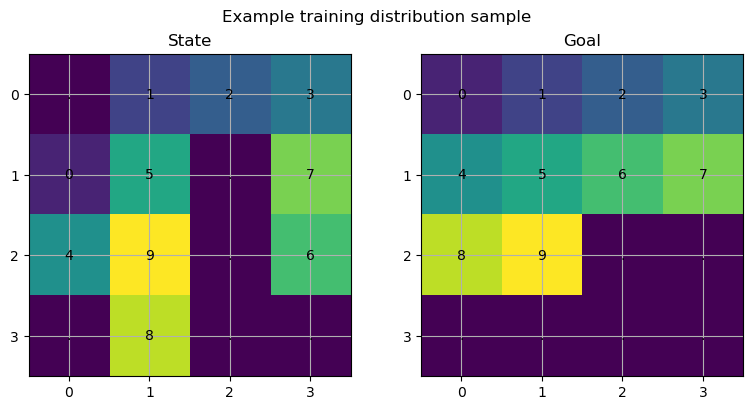

Observation dimension: 352
Action dimension: 40


In [4]:
env_config = EnvConfig(
    size=4,
    n_objects=10,
    move_mode="step",      # change to "slide" if needed
    scramble_steps=10,
    max_steps=50,
    step_penalty=-0.3,
    invalid_penalty=-0.7,
    goal_reward=12.0,
    shaping_scale=0.4,
    random_goal=False,
    seed=7,
)

start_state, goal_state = generate_fixed_sample(env_config, seed=123)
plot_state_and_goal(start_state, goal_state, env_config.size, env_config.n_objects, title="Example training distribution sample")
print("Observation dimension:", GridRearrangementEnv(env_config).obs_dim)
print("Action dimension:", GridRearrangementEnv(env_config).num_actions)

## Training configuration

- `dqn_config` is used for both **DQN** and **Double DQN**
- `ppo_config` is used for **PPO**

Start with these settings, then scale them up if the models are not solving enough of the training distribution.

In [5]:
algorithms_to_train = ["dqn", "ddqn", "ppo"]
model_dir = Path("saved_models_deep_rl")
model_dir.mkdir(exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

# Shared config for DQN and Double DQN
dqn_config = DQNConfig(
    episodes=800,
    buffer_size=100_000,
    batch_size=128,
    gamma=0.99,
    lr=3e-4,
    hidden_dims=(256, 256),
    learning_starts=1000,
    train_freq=1,
    gradient_steps=1,
    target_update_interval=250,
    start_epsilon=1.0,
    end_epsilon=0.05,
    epsilon_decay_fraction=0.60,
    max_grad_norm=10.0,
    seed=7,
)

ppo_config = PPOConfig(
    total_timesteps=40_000,
    rollout_steps=1024,
    epochs=10,
    minibatch_size=256,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.20,
    lr=3e-4,
    entropy_coef=0.01,
    value_coef=0.5,
    max_grad_norm=0.5,
    hidden_dims=(256, 256),
    seed=7,
)

print("Algorithms:", algorithms_to_train)
print("Model directory:", model_dir.resolve())

Algorithms: ['dqn', 'ddqn', 'ppo']
Model directory: C:\Users\Administrator\Desktop\CogntiveLLMsStudy\saved_models_deep_rl


## Train and save checkpoints

Set `RUN_TRAINING = True` to train from scratch.

If checkpoints already exist and `RUN_TRAINING = False`, the notebook will skip training and just point to the saved model files.

In [6]:
RUN_TRAINING = True

model_paths = {
    "dqn": model_dir / f"dqn_grid{env_config.size}_obj{env_config.n_objects}.pt",
    "ddqn": model_dir / f"ddqn_grid{env_config.size}_obj{env_config.n_objects}.pt",
    "ppo": model_dir / f"ppo_grid{env_config.size}_obj{env_config.n_objects}.pt",
}

if RUN_TRAINING:
    agents, histories, model_paths = train_selected_algorithms(
        algorithms=algorithms_to_train,
        env_config=env_config,
        dqn_config=dqn_config,
        ppo_config=ppo_config,
        model_dir=model_dir,
        device=device,
        verbose=True,
    )
else:
    agents = {}
    histories = {}
    missing = [algo for algo in algorithms_to_train if not model_paths[algo].exists()]
    if missing:
        raise FileNotFoundError(f"Missing checkpoints for: {missing}. Set RUN_TRAINING=True first.")

model_paths

[DQN] episode 1/800 | avg_return=-15.400 | solve_rate=0.00% | epsilon=0.998
[DQN] episode 80/800 | avg_return=-16.224 | solve_rate=0.00% | epsilon=0.842
[DQN] episode 160/800 | avg_return=-14.996 | solve_rate=4.00% | epsilon=0.686
[DQN] episode 240/800 | avg_return=-15.280 | solve_rate=2.00% | epsilon=0.530
[DQN] episode 320/800 | avg_return=-5.076 | solve_rate=40.00% | epsilon=0.409
[DQN] episode 400/800 | avg_return=6.292 | solve_rate=90.00% | epsilon=0.341
[DQN] episode 480/800 | avg_return=-15.072 | solve_rate=0.00% | epsilon=0.191
[DQN] episode 560/800 | avg_return=-12.324 | solve_rate=14.00% | epsilon=0.050
[DQN] episode 640/800 | avg_return=-3.248 | solve_rate=46.00% | epsilon=0.050
[DQN] episode 720/800 | avg_return=-5.552 | solve_rate=38.00% | epsilon=0.050
[DQN] episode 800/800 | avg_return=-16.312 | solve_rate=0.00% | epsilon=0.050
[DDQN] episode 1/800 | avg_return=-15.400 | solve_rate=0.00% | epsilon=0.998
[DDQN] episode 80/800 | avg_return=-15.588 | solve_rate=2.00% | epsi

{'dqn': WindowsPath('saved_models_deep_rl/dqn_grid4_obj10.pt'),
 'ddqn': WindowsPath('saved_models_deep_rl/ddqn_grid4_obj10.pt'),
 'ppo': WindowsPath('saved_models_deep_rl/ppo_grid4_obj10.pt')}

## Plot training curves

Run this after training. It plots the history for each algorithm that was trained in this session.

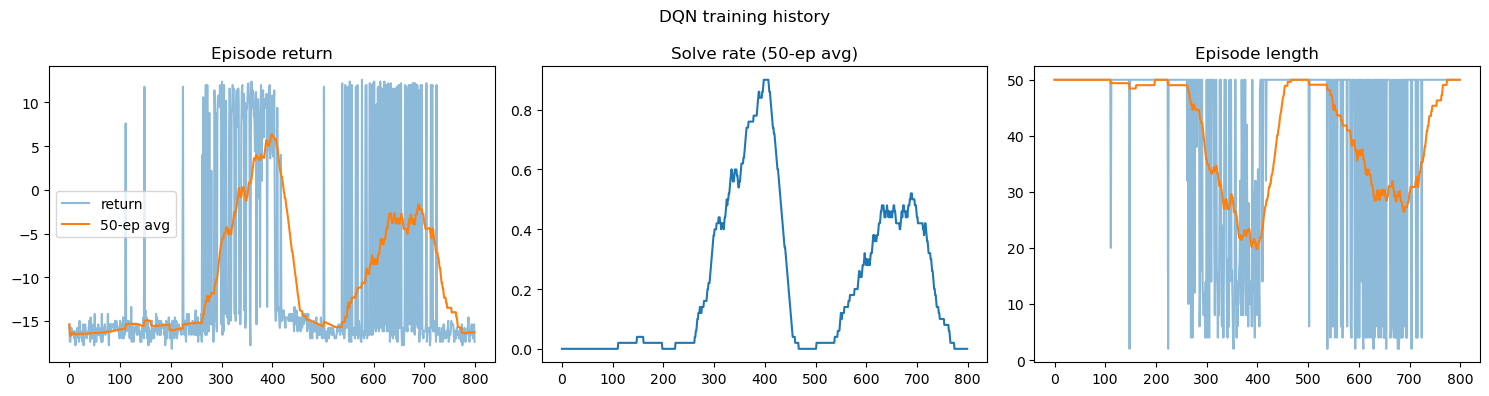

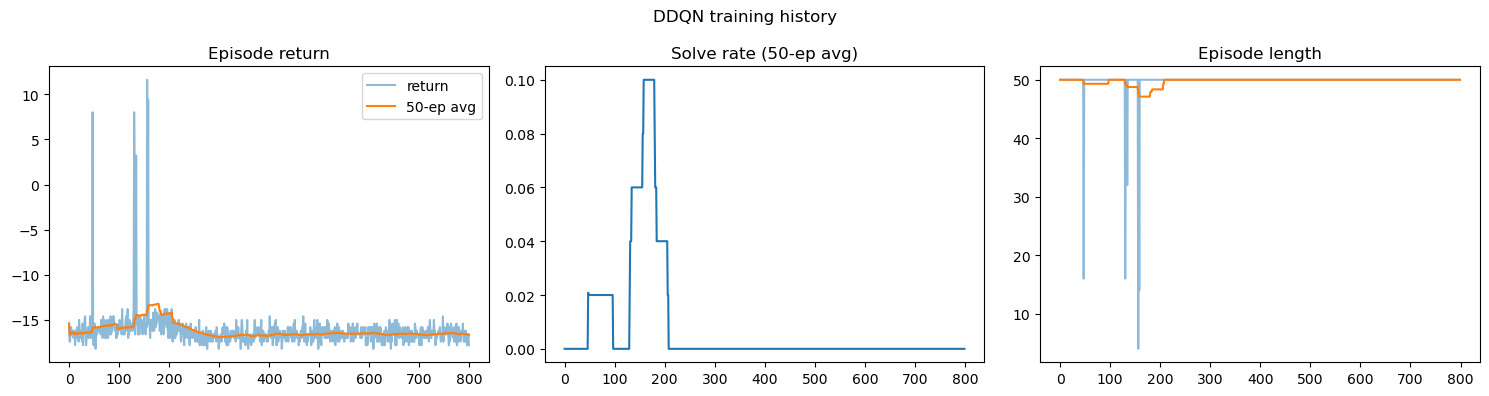

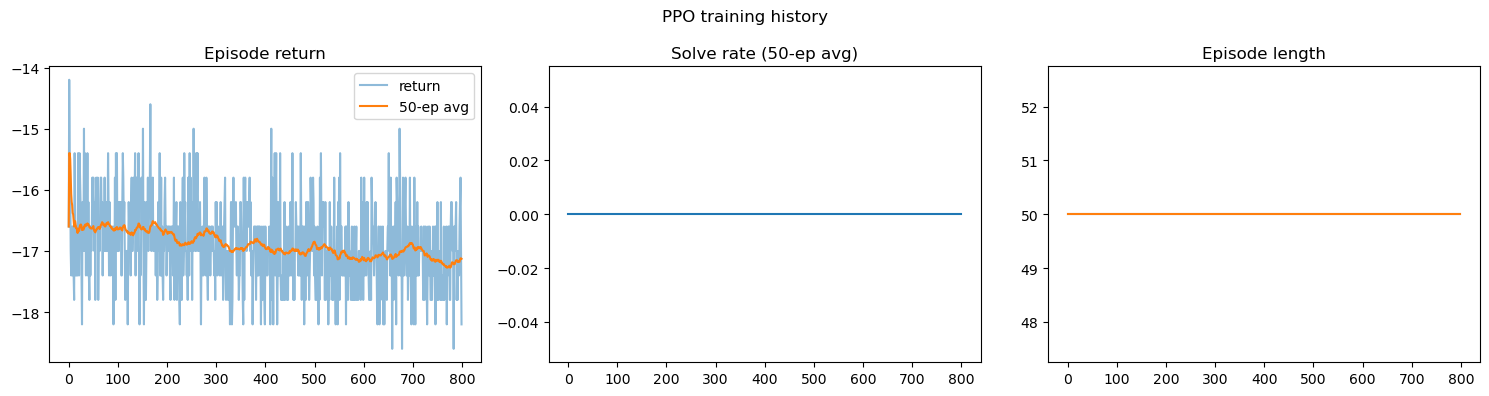

In [7]:
for algo, history in histories.items():
    plot_training_history(history, title=f"{algo.upper()} training history")

## Evaluate all saved models on the same puzzle sample

The next cell generates a **single fixed sample** and runs all three saved models on that exact same start state and goal state.

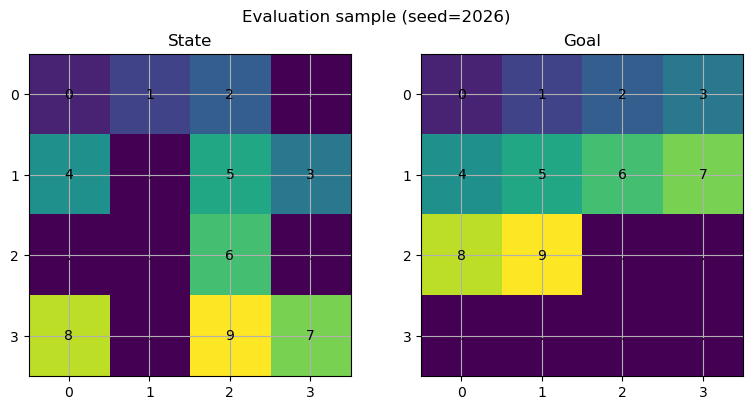

algorithm | solved | steps | total_reward | invalid_actions | correct_objects
----------+--------+-------+--------------+-----------------+----------------
dqn       | False  | 50    | -16.6        | 0               | 0              
ddqn      | False  | 50    | -16.2        | 0               | 1              
ppo       | False  | 50    | -16.2        | 0               | 1              
Saved comparison summary to: C:\Users\Administrator\Desktop\CogntiveLLMsStudy\saved_models_deep_rl\latest_comparison_summary.json


In [8]:
sample_seed = 2026
start_state, goal_state = generate_fixed_sample(env_config, seed=sample_seed)
plot_state_and_goal(start_state, goal_state, env_config.size, env_config.n_objects, title=f"Evaluation sample (seed={sample_seed})")

results = evaluate_saved_models(
    model_paths=model_paths,
    env_config=env_config,
    start_state=start_state,
    goal_state=goal_state,
    device=device,
)

rows = comparison_rows(results)
print_comparison_table(rows)

summary_path = model_dir / "latest_comparison_summary.json"
save_json_summary(rows, summary_path)
print(f"Saved comparison summary to: {summary_path.resolve()}")

## Visualize the rollout from each model

This helps you compare how the three policies behave on the same evaluation sample.


=== DQN ===
Solved: False
Steps: 50
Total reward: -16.600
Correct objects in final state: 0
First actions: ['obj=6 left', 'obj=6 left', 'obj=5 down', 'obj=5 right', 'obj=3 up', 'obj=1 down', 'obj=1 down', 'obj=1 down', 'obj=0 right', 'obj=0 down', 'obj=2 left', 'obj=2 left']


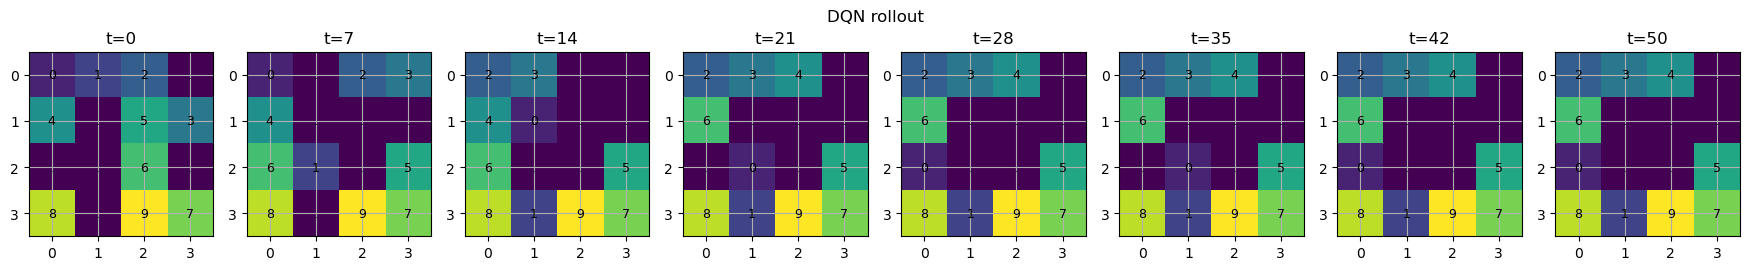


=== DDQN ===
Solved: False
Steps: 50
Total reward: -16.200
Correct objects in final state: 1
First actions: ['obj=6 right', 'obj=4 down', 'obj=2 right', 'obj=4 right', 'obj=9 left', 'obj=1 down', 'obj=6 left', 'obj=6 right', 'obj=6 left', 'obj=6 right', 'obj=6 left', 'obj=6 right']


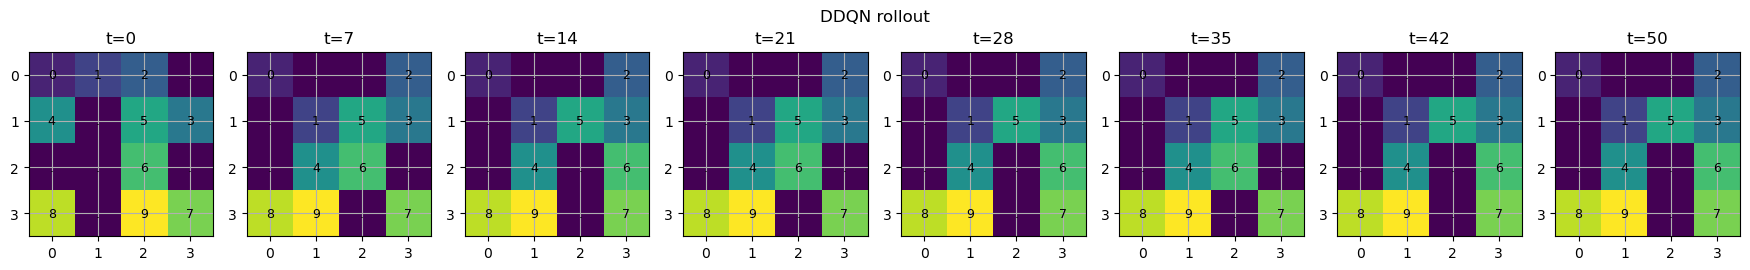


=== PPO ===
Solved: False
Steps: 50
Total reward: -16.200
Correct objects in final state: 1
First actions: ['obj=6 left', 'obj=6 left', 'obj=4 right', 'obj=9 up', 'obj=4 down', 'obj=4 down', 'obj=4 right', 'obj=3 down', 'obj=1 down', 'obj=1 down', 'obj=1 down', 'obj=0 right']


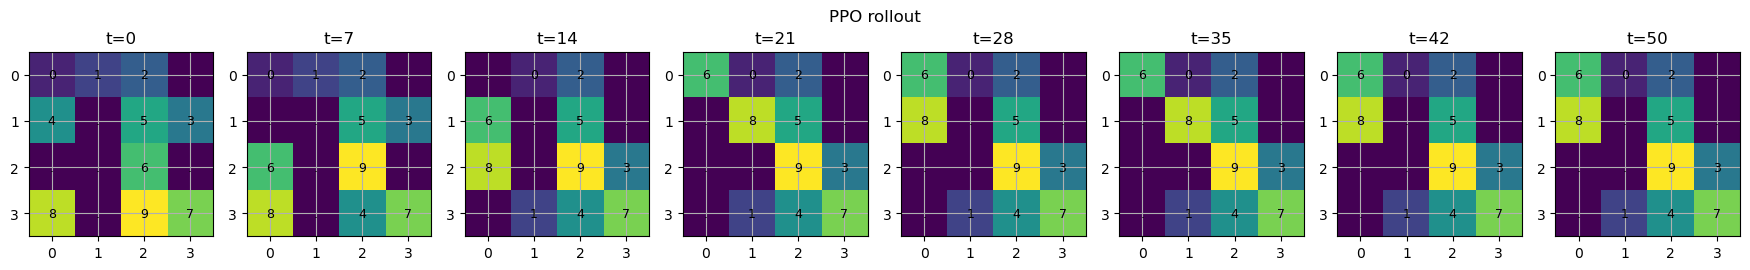

In [9]:
for algo, summary in results.items():
    print(f"\n=== {algo.upper()} ===")
    print(f"Solved: {summary.solved}")
    print(f"Steps: {summary.steps}")
    print(f"Total reward: {summary.total_reward:.3f}")
    print(f"Correct objects in final state: {summary.correct_objects}")
    if summary.actions:
        action_names = [GridRearrangementEnv(env_config).action_to_str(a) for a in summary.actions[:12]]
        print("First actions:", action_names)
    plot_rollout_states(summary.states, env_config.size, max_panels=8, title=f"{algo.upper()} rollout")

## Load a checkpoint later without retraining

This cell shows how to reload any saved model in a fresh notebook session.

In [10]:
loaded_dqn = load_agent(model_paths["dqn"], device=device)
loaded_ddqn = load_agent(model_paths["ddqn"], device=device)
loaded_ppo = load_agent(model_paths["ppo"], device=device)

print(type(loaded_dqn).__name__, loaded_dqn.algo_name)
print(type(loaded_ddqn).__name__, loaded_ddqn.algo_name)
print(type(loaded_ppo).__name__, loaded_ppo.algo_name)

DeepQAgent dqn
DeepQAgent ddqn
PPOAgent ppo


## Notes

- The current notebook focuses **only** on **DQN**, **Double DQN**, and **PPO**.
- The state is encoded symbolically as a goal-conditioned one-hot representation.
- Action masking is used so the policies only choose legal moves.
- For the larger 4x4 / 10-object setting, performance depends strongly on reward shaping and training budget.
- If you want stronger results later, the next natural additions are curriculum learning, larger networks, or richer goal randomization.